# Image Features Analysis with PCA

## Libraries importations and preprocessing
Note : All elements in this first section have already been described in the basic_model notebook.

In [1]:
import tensorflow as tf
from tensorflow import keras as tfk
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sn
from matplotlib import cm
from plotly import graph_objects as go

import albumentations as A
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import random
import cv2 as cv
import torch
from torchvision import transforms, models
from PIL import Image

np.random.seed(42)
tf.random.set_seed(42)

/opt/conda/lib/python3.10/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.22 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
%cd "/kaggle/input"
data = np.load("mars-dataset/mars_for_students.npz")

training_set = data["training_set"]

X_train_original = training_set[:, 0]
y_train_original = training_set[:, 1]

labels = {0:'Background', 1:'Soil', 2:'Bedrock', 3:'Sand', 4:'Big Rocks'}

/kaggle/input


In [3]:
from sklearn.metrics.pairwise import cosine_similarity

def find_duplicates_with_similarity(y_train, similarity_threshold=0.9):
    y_reshaped = y_train.reshape(y_train.shape[0], -1)
    
    # Compute pairwise cosine similarity
    similarity_matrix = cosine_similarity(y_reshaped)

    # Keep track of visited indices
    visited = set()
    duplicates_info = {}

    for i in range(len(similarity_matrix)):
        if i in visited:
            continue

        # Find all indices similar to the current label
        similar_indices = np.where(similarity_matrix[i] >= similarity_threshold)[0]
        similar_indices = set(similar_indices) - visited

        if len(similar_indices) > 1:  # Only consider groups with duplicates
            duplicates_info[tuple(similar_indices)] = len(similar_indices)

        # Mark these indices as visited
        visited.update(similar_indices)

    return duplicates_info

duplicates_info = find_duplicates_with_similarity(y_train_original, similarity_threshold=0.97)

def get_indices_to_remove(y_train, label_to_remove):
    y_reshaped = y_train.reshape(y_train.shape[0], -1)
    label_flat = label_to_remove.reshape(1, -1)
    indices_to_remove = np.where(np.all(y_reshaped == label_flat, axis=1))[0]
    return indices_to_remove

def remove_indices(X_train, y_train, indices_to_remove):
    mask = np.ones(X_train.shape[0], dtype=bool)  # Create a mask of all True
    mask[indices_to_remove] = False  # Set False for indices to remove
    X_train_new = X_train[mask]
    y_train_new = y_train[mask]
    return X_train_new, y_train_new

# The label to remove
label_to_remove = y_train_original[2561]  # Take one of the labels from the identified images containing the Alien

indices_to_remove = get_indices_to_remove(y_train_original, label_to_remove)
X_train_cleaned, y_train_cleaned = remove_indices(X_train_original, y_train_original, indices_to_remove)
#print(f"Indices to remove: {indices_to_remove}")
print(f"Original train shape: {X_train_original.shape}, New shape: {X_train_cleaned.shape}")

Original train shape: (2615, 64, 128), New shape: (2505, 64, 128)


## Features extraction
We isolate the labels in the images to get a subset of single-labels images (800) from which we can extract the features with a pretrained VGG16. This represents the output of the encoder of a typical UNet. The goal is then to visualize those features in a reduced-dimensions space.

In [4]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
import numpy as np

# Load VGG16 without the top dense layers, focusing on convolutional layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64, 128, 3))
bottleneck_layer_name = 'block5_pool'
bottleneck_output = base_model.get_layer(bottleneck_layer_name).output
feature_extractor = Model(inputs=base_model.input, outputs=bottleneck_output)

# Function to preprocess the images
def preprocess_images(images):
    preprocessed_batch = []
    for img in images:
        img = tf.convert_to_tensor(img, dtype=tf.float32)
        img = tf.expand_dims(img, axis=-1) 
        img = tf.image.grayscale_to_rgb(img) 
        img = tf.image.resize(img, (64, 128))  
        preprocessed_batch.append(img)
    return tf.stack(preprocessed_batch, axis=0)

def filter_single_label_images(images, masks):
    """
    Keep images where the corresponding label mask contains only one unique label.
    """
    filtered_images = []
    filtered_masks = []
    for img, mask in zip(images, masks):
        unique_labels = np.unique(mask)
        if len(unique_labels) == 1:  # Single label only
            filtered_images.append(img)
            filtered_masks.append(mask)
    return filtered_images, filtered_masks

def isolate_labels(images, masks):
    """
    For multi-label masks, generate isolated label images.
    """
    isolated_images = []
    isolated_labels = []
    for img, mask in zip(images, masks):
        unique_labels = np.unique(mask)
        for label in unique_labels:
            if label == 0:  # Skip background label
                continue
            binary_mask = (mask == label).astype(np.float32)
            isolated_img = img * binary_mask
            isolated_images.append(isolated_img)
            isolated_labels.append(label)
    return isolated_images, isolated_labels

features = []
batch_size = 64

multi_label_images, multi_label_masks = isolate_labels(X_train_cleaned, y_train_cleaned)
single_label_images, single_label_masks = filter_single_label_images(X_train_cleaned, y_train_cleaned)
final_images = single_label_images + multi_label_images
final_masks = single_label_masks + multi_label_masks

# Process images in batches
for start in range(0, len(final_images), batch_size):
    end = start + batch_size
    batch = final_images[start:end]
    preprocessed_batch = preprocess_images(batch)
    batch_features = feature_extractor(preprocessed_batch) 
    batch_features = tf.reshape(batch_features, (batch_features.shape[0], -1))

    features.append(batch_features.numpy())

# Combine all batches into a single array
features = np.vstack(features)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
features_df = []
for i in range(800):
    features_df.append(features[i].tolist())

features_df = np.asarray(features_df)
print(features_df.shape)

(800, 4096)


In [9]:
y_labels = []
for i in range(800):
    label = np.unique(final_masks[i])
    y_labels.append(int(label[0]))

## PCA for dimension reduction
We will keep only the first 3 components to be able to visualize the features in space. It will be a glance at how the model sees the data before sending it to its classifier.

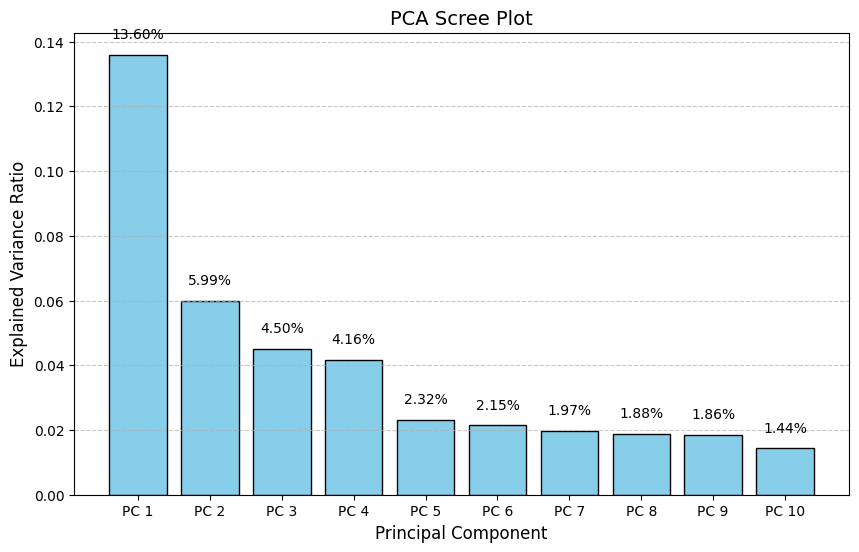

In [7]:
N_COMPONENTS = 10

pca = PCA(n_components=N_COMPONENTS)
pca.fit(features_df)

# PCA results
x = list(range(1, N_COMPONENTS + 1))
y = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.bar(x, y, color='skyblue', edgecolor='black')
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.title('PCA Scree Plot', fontsize=14)
plt.xticks(ticks=x, labels=[f"PC {i}" for i in x])
plt.grid(axis='y', linestyle='--', alpha=0.8)

for i, v in enumerate(y):
    plt.text(x[i], v + 0.005, f"{v:.2%}", ha='center', fontsize=10)

# Display the plot
plt.show()

We can clearly see how some classes are much more easily separable in this space than others. The Sand, Soil and Bedrock are much easier classes than Background and Big Rocks which have both less samples and less distinctive features.

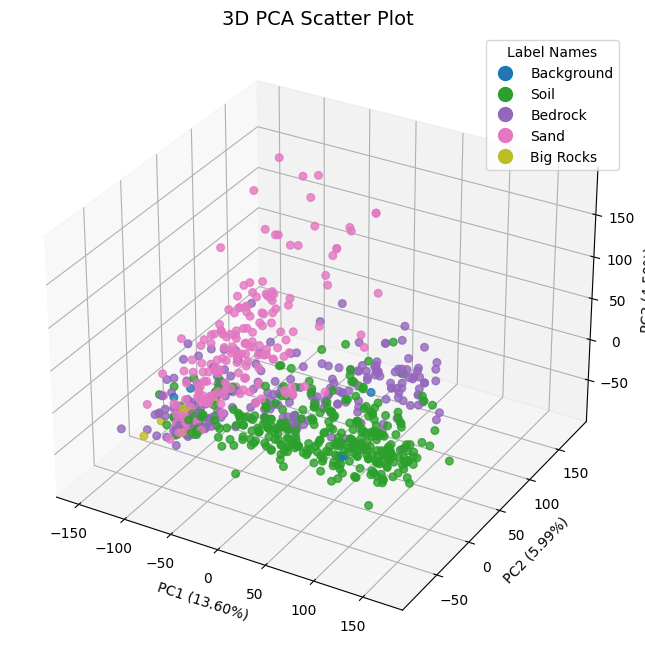

In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fitted = pca.transform(features_df)

# Create a colormap
unique_labels = np.unique(y_labels)
colors = plt.cm.tab10(unique_labels / len(unique_labels))  # Generate a color for each label
color_map = {label: colors[i] for i, label in enumerate(unique_labels)}  # Map labels to colors

# Map y_labels to colors for scatter plot
scatter_colors = [color_map[label] for label in y_labels]

# Create the 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    fitted[:, 0], fitted[:, 1], fitted[:, 2],
    c=scatter_colors, s=30, alpha=0.8, edgecolor=None
)

# Set labels and title
ax.set_title('3D PCA Scatter Plot', fontsize=14)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%})')

# Add a custom legend
legend_handles = [
    plt.Line2D([0], [0], marker='o', color=color_map[label], markersize=10, linestyle='None', label=labels[label])
    for label in unique_labels
]
ax.legend(handles=legend_handles, title="Label Names", loc='upper right', fontsize=10)

# Show the plot
plt.show()
